In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/Lungs_Disease.zip"
extract_path = "/content/Lung_Disease"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print("Files extracted to:", extract_path)
print("all ok")

Unzipped successfully!
Files extracted to: /content/Lung_Disease
all ok


In [4]:
import os

dataset_path = "/content/Lung_Disease"

print(os.listdir(dataset_path))

['Lung Disease Dataset']


In [5]:
import shutil

shutil.rmtree("/content/Lung_Disease/Lung Disease Dataset/test/Viral Pneumonia", ignore_errors=True)
shutil.rmtree("/content/Lung_Disease/Lung Disease Dataset/train/Viral Pneumonia", ignore_errors=True)
shutil.rmtree("/content/Lung_Disease/Lung Disease Dataset/val/Viral Pneumonia", ignore_errors=True)

print("Folder deleted successfully!")

Folder deleted successfully!


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Dataset paths
train_path = "/content/Lung_Disease/Lung Disease Dataset/train"
test_path = "/content/Lung_Disease/Lung Disease Dataset/test"
val_path = "/content/Lung_Disease/Lung Disease Dataset/val"

# Function to count images in each class
def count_images(folder_path):
    class_counts = {}

    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)

        if os.path.isdir(class_folder):
            count = len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_counts[class_name] = count

    return class_counts

# Count train and test images
train_counts = count_images(train_path)
test_counts = count_images(test_path)
val_counts = count_images(val_path)

# Convert to DataFrame
train_df = pd.DataFrame({
    "Class": list(train_counts.keys()),
    "Count": list(train_counts.values())
})

test_df = pd.DataFrame({
    "Class": list(test_counts.keys()),
    "Count": list(test_counts.values())
})

val_df = pd.DataFrame({
    "Class": list(val_counts.keys()),
    "Count": list(val_counts.values())
})

# Print counts
print("Train Class Counts:")
print(train_df)

print("\nTest Class Counts:")
print(test_df)

print("\nValidation Class Counts:")
print(val_df)

Train Class Counts:
                  Class  Count
0          Tuberculosis   1220
1   Bacterial Pneumonia   1205
2                Normal   1207
3  Corona Virus Disease   1218

Test Class Counts:
                  Class  Count
0          Tuberculosis    408
1   Bacterial Pneumonia    403
2                Normal    404
3  Corona Virus Disease    407

Validation Class Counts:
                  Class  Count
0          Tuberculosis    406
1   Bacterial Pneumonia    401
2                Normal    402
3  Corona Virus Disease    406


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, Activation,
    Add, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout,
    Multiply, Reshape, Lambda
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [8]:
# =============================================================
# DATASET PATHS
# =============================================================
train_dir = "/content/Lung_Disease/Lung Disease Dataset/train"
test_dir  = "/content/Lung_Disease/Lung Disease Dataset/test"
val_dir  = "/content/Lung_Disease/Lung Disease Dataset/val"

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

In [9]:
# =============================================================
# DATA GENERATORS — Strong augmentation for medical images
# =============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # brain MRIs can be slightly rotated
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],  # MRI contrast variation
    shear_range=0.05
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print(f"Classes: {train_data.class_indices}")
print(f"Train batches: {len(train_data)} | Test batches: {len(val_data)}")

Found 4850 images belonging to 4 classes.
Found 1615 images belonging to 4 classes.
Found 1622 images belonging to 4 classes.
Classes: {'Bacterial Pneumonia': 0, 'Corona Virus Disease': 1, 'Normal': 2, 'Tuberculosis': 3}
Train batches: 152 | Test batches: 51


In [10]:
# =============================================================
# BUILDING BLOCKS
# =============================================================

def depthwise_sep_conv(x, filters, stride=1):
    """
    Depthwise Separable Convolution block.
    ~8x fewer parameters than standard Conv2D of the same filter size.
    """
    x = DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, 1, padding='same', use_bias=False)(x)  # pointwise
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x


def se_block(x, ratio=8):
    """
    Squeeze-and-Excitation block.
    Learns channel-wise attention: which feature maps are important.
    ratio=8 keeps parameter overhead tiny (~2*C^2/ratio params).
    """
    channels = x.shape[-1]
    # Squeeze: global context
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, channels))(se)
    # Excitation: learn to re-weight channels
    se = Conv2D(max(channels // ratio, 4), 1, activation='relu', use_bias=False)(se)
    se = Conv2D(channels, 1, activation='sigmoid', use_bias=False)(se)
    # Scale
    return Multiply()([x, se])


def residual_ds_block(x, filters, downsample=False):
    """
    Residual block using Depthwise Separable Convolutions + SE attention.
    If channel count changes or spatial dims change, uses a 1x1 projection shortcut.
    """
    stride = 2 if downsample else 1
    shortcut = x

    # Main path
    x = depthwise_sep_conv(x, filters, stride=stride)
    x = depthwise_sep_conv(x, filters, stride=1)
    x = se_block(x)  # channel attention

    # Projection shortcut if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

In [11]:
# =============================================================
# MODEL ARCHITECTURE
# =============================================================
# Design rationale:
# - Stem: standard conv (preserves early low-level texture details)
# - Stage 1-4: Residual DS blocks with SE attention
# - Progressive widening: 32→64→128→256 channels
# - Stages 2,3,4 downsample spatially (stride=2), keeping compute manageable
# - Head: GAP (removes spatial dims) + single 256-unit Dense + output
#
# Total estimated params: ~1.1–1.4M (vs VGG16's 6.5M)
# =============================================================

def build_model(num_classes, input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # --- STEM ---
    # Standard 3x3 conv first: captures raw low-level MRI textures
    x = Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)  # 112x112
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(2)(x)  # 56x56

    # --- STAGE 1 — 64 channels ---
    x = residual_ds_block(x, 64, downsample=False)  # 56x56
    x = residual_ds_block(x, 64, downsample=False)  # 56x56

    # --- STAGE 2 — 128 channels ---
    x = residual_ds_block(x, 128, downsample=True)  # 28x28
    x = residual_ds_block(x, 128, downsample=False) # 28x28
    x = residual_ds_block(x, 128, downsample=False) # 28x28

    # --- STAGE 3 — 256 channels ---
    x = residual_ds_block(x, 256, downsample=True)  # 14x14
    x = residual_ds_block(x, 256, downsample=False) # 14x14
    x = residual_ds_block(x, 256, downsample=False) # 14x14

    # --- STAGE 4 — 512 channels (optional, comment out to save params) ---
    # Uncomment if you want more capacity (~+500K params):
    # x = residual_ds_block(x, 512, downsample=True)  # 7x7
    # x = residual_ds_block(x, 512, downsample=False) # 7x7

    # --- HEAD ---
    x = GlobalAveragePooling2D()(x)  # replaces Flatten — much more efficient
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='EfficientBrainNet')
    return model


model = build_model(NUM_CLASSES)
model.summary()

Model: "EfficientBrainNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 56, 56,    │        288 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      2,048 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │        576 │ re_lu_3[0][0]     │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 690,948 (2.64 MB)

 Trainable params: 680,132 (2.59 MB)

 Non-trainable params: 10,816 (42.25 KB)

In [12]:
# =============================================================
# COMPILE
# =============================================================
# Label smoothing: reduces overconfidence, improves generalization
# Particularly helpful for medical datasets where boundary cases exist

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [13]:
# =============================================================
# CALLBACKS
# =============================================================
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',  # watch accuracy, not just loss
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lungs_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [14]:
# =============================================================
# TRAINING — Phase 1: Warm up
# =============================================================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.5919 - loss: 1.1580
Epoch 1: val_accuracy improved from None to 0.25139, saving model to best_lungs_model.keras

Epoch 1: finished saving model to best_lungs_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.6977 - loss: 0.9587 - val_accuracy: 0.2514 - val_loss: 2.3061 - learning_rate: 0.0010
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.8281 - loss: 0.7275
Epoch 2: val_accuracy did not improve from 0.25139
152/152 ━━━━━━━━━━━━━━━━━━━━ 129s 846ms/step - accuracy: 0.8330 - loss: 0.7178 - val_accuracy: 0.2514 - val_loss: 2.3796 - learning_rate: 0.0010
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.8639 - loss: 0.6693
Epoch 3: val_accuracy improved from 0.25139 to 0.36285, saving model to best_lungs_model.keras

Epoch 3: finished saving model to best_lungs_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 130s 853ms/step - accuracy: 0.8680 - loss: 0.6606 - val_accuracy: 

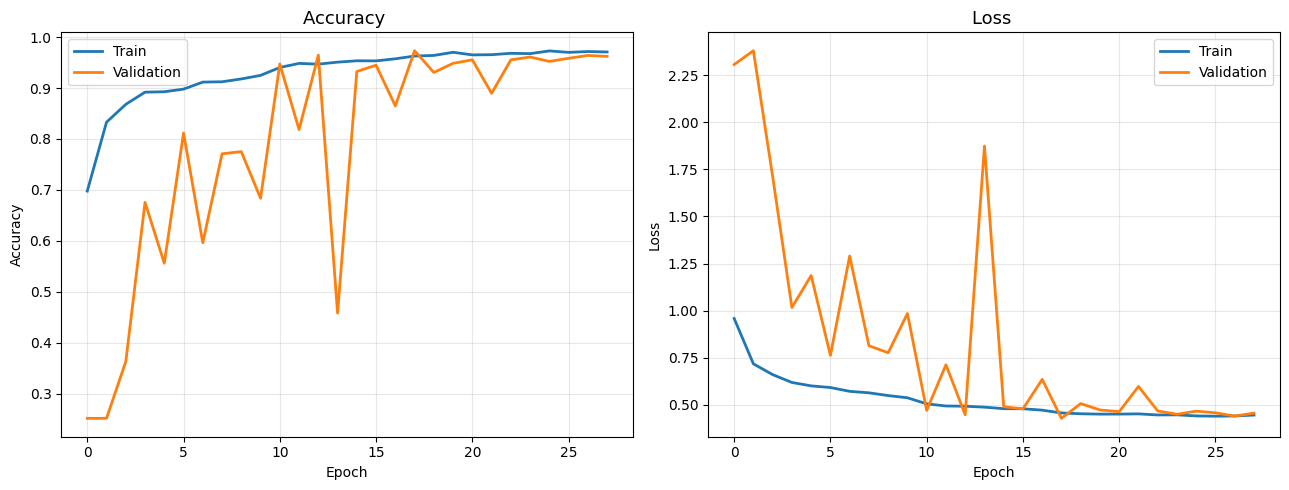

In [15]:
# =============================================================
# TRAINING CURVES
# =============================================================
def plot_history(h, title_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(h.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(h.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title(f'Accuracy {title_suffix}', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(h.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(h.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title(f'Loss {title_suffix}', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, '')
# plot_history(history_ft, '— Phase 2 Fine-tune')  # uncomment if you ran phase 2

51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 593ms/step


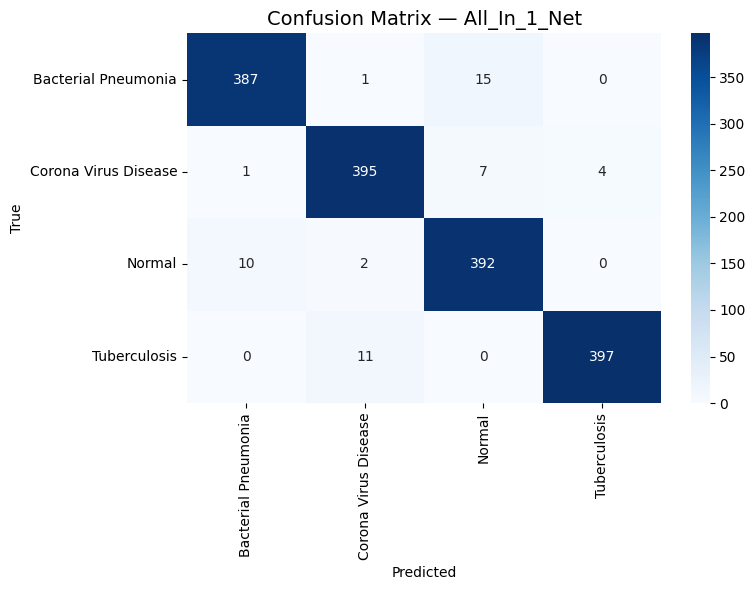


CLASSIFICATION REPORT
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.97      0.96      0.97       403
Corona Virus Disease       0.97      0.97      0.97       407
              Normal       0.95      0.97      0.96       404
        Tuberculosis       0.99      0.97      0.98       408

            accuracy                           0.97      1622
           macro avg       0.97      0.97      0.97      1622
        weighted avg       0.97      0.97      0.97      1622


>>> Final Test Accuracy: 96.86%
>>> Model Parameters: 690,948


In [16]:
# =============================================================
# EVALUATION
# =============================================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model.predict(test_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_data.classes
class_names  = list(test_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — All_In_1_Net', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Overall accuracy
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print(f"\n>>> Final Test Accuracy: {test_acc*100:.2f}%")
print(f">>> Model Parameters: {model.count_params():,}")

Class Mapping:
{0: 'Bacterial Pneumonia', 1: 'Corona Virus Disease', 2: 'Normal', 3: 'Tuberculosis'}


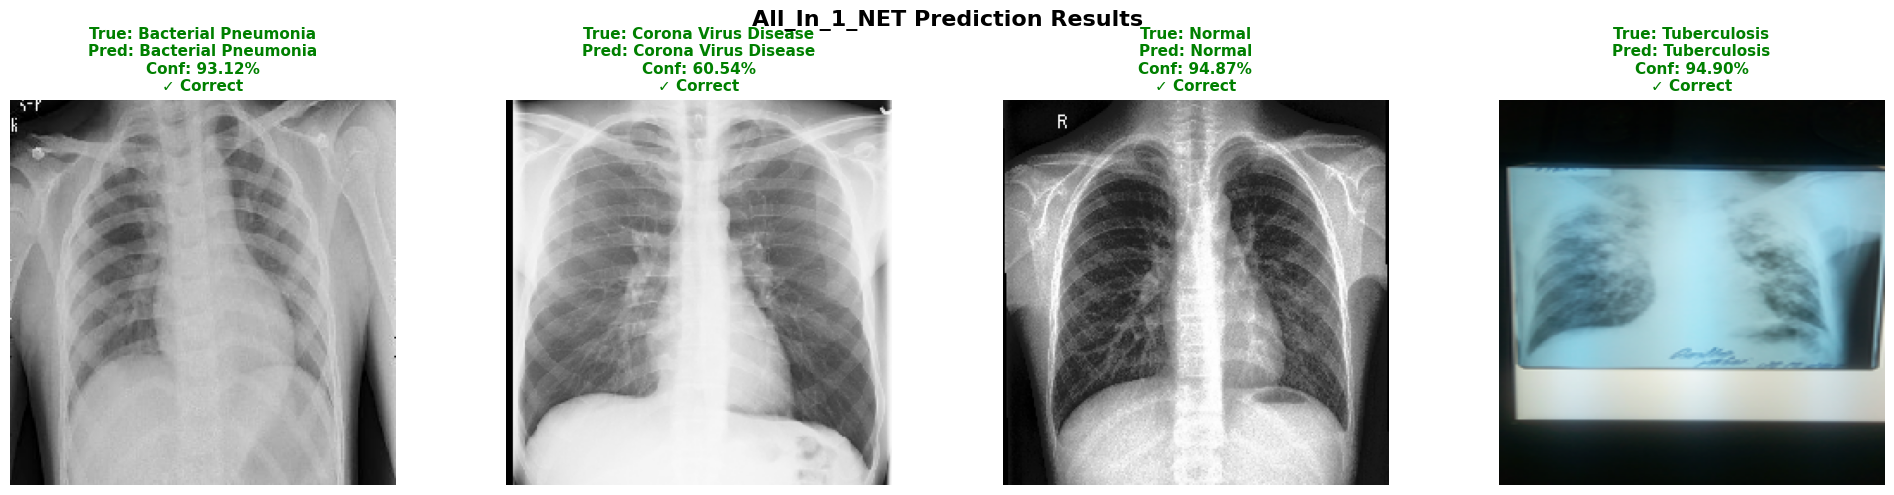


Saved -> prediction_results.png


In [17]:
# =============================================================
# ONE RANDOM IMAGE PER CLASS - PREDICTION VISUALIZATION
# =============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage

# -------------------------------------------------------------
# CLASS MAPPING
# -------------------------------------------------------------

class_indices = test_data.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print("Class Mapping:")
print(idx_to_class)

# -------------------------------------------------------------
# GET CLASS NAMES
# -------------------------------------------------------------

class_names = list(class_indices.keys())

# -------------------------------------------------------------
# RANDOMLY SELECT ONE IMAGE FROM EACH CLASS
# (Different every execution)
# -------------------------------------------------------------

selected_images = {}

for cls in class_names:

    cls_dir = os.path.join(test_dir, cls)

    files = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(files) == 0:
        print(f"No images found in {cls_dir}")
        continue

    selected_images[cls] = random.choice(files)

# -------------------------------------------------------------
# CREATE FIGURE
# -------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(selected_images),
    figsize=(5 * len(selected_images), 5)
)

if len(selected_images) == 1:
    axes = [axes]

# -------------------------------------------------------------
# PREDICT & DISPLAY
# -------------------------------------------------------------

for ax, (true_class, img_path) in zip(axes, selected_images.items()):

    # Load image
    img = kimage.load_img(img_path, target_size=(224, 224))

    img_array = kimage.img_to_array(img)
    img_array = img_array.astype("float32") / 255.0

    img_input = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_input, verbose=0)

    pred_idx = np.argmax(preds[0])
    pred_class = idx_to_class[pred_idx]
    confidence = preds[0][pred_idx] * 100

    correct = (true_class == pred_class)

    # Display image
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {pred_class}\n"
        f"Conf: {confidence:.2f}%\n"
        f"{'✓ Correct' if correct else '✗ Wrong'}",
        fontsize=11,
        color="green" if correct else "red",
        fontweight="bold"
    )

# -------------------------------------------------------------
# SAVE FIGURE
# -------------------------------------------------------------

plt.suptitle(
    "All_In_1_NET Prediction Results",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "prediction_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved -> prediction_results.png")

In [18]:
from google.colab import files

files.download('/content/best_lungs_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>